In [1]:
import sys
sys.path.append('/Users/theodorehuppert/Desktop/NIRS_Python/pyNIRS_toolbox')

import cedalion
import cedalion.datasets


# All the processing modules are in pipelines.modules
import pyBrainAnalyzIR.pipelines.modules.preproccessing as prep
import pyBrainAnalyzIR.pipelines.modules.events as events
import pyBrainAnalyzIR.pipelines.modules.glm as stats


# This will allow matplotlib to work as a widget (needs "pip install ipympl")
%matplotlib widget

rec = cedalion.datasets.get_fingertapping()


# Just like in AnalyzIR, you can string module objects together to make full pipelines

job = events.rename_stims()
job.options['ListofChanges']={
        "1.0": "control",
        "2.0": "Tapping/Left",
        "3.0": "Tapping/Right",
        "15.0": "start marker",
    }
job = events.remove_stims(job)
job.options['ListtoRemove']=["start marker"]
job = prep.intensity_opticaldensity(job)
job = prep.mbll(job)
job =prep.resample(job)
job.options['Fs']=1
job = stats.GLM(job)
job.options['noise_model']='ar_irls'
job.options['Add_Short_Seperations']=True
job.options['max_jobs']=12

rec=job.run(rec)


 50%|█████     | 1/2 [00:00<00:00,  8.01it/s]


In [2]:
job.options

{'noise_model': 'ar_irls',
 'ar_order': 30,
 'max_jobs': 12,
 'basis_function': <cedalion.models.glm.basis_functions.Gamma at 0x166856350>,
 'Add_Short_Seperations': True,
 'Short_Seperation_Max_Distance': <Quantity(1.5, 'centimeter')>,
 'drift_order': 0,
 'verbose': True}

In [3]:
stats=rec['stats']
stats.remove_condition('Drift 0')
stats.remove_condition('short')
stats.list_conditions()

array(['HRF Tapping/Left', 'HRF Tapping/Right', 'HRF control'],
      dtype='<U17')

In [4]:
stats.table()

,Channel,Type,Condition,Beta,StdErr,T-value,P-values,Q-values
0,S1D1,HbO,HRF control,-0.028760,0.030859,-0.932005,3.514097e-01,4.529401e-01
1,S1D1,HbO,HRF Tapping/Left,0.267074,0.030887,8.646797,8.518131e-18,2.839377e-17
2,S1D1,HbO,HRF Tapping/Right,0.338481,0.030924,10.945557,2.308580e-27,1.458050e-26
3,S1D2,HbO,HRF control,0.004422,0.007927,0.557843,5.769937e-01,6.411041e-01
4,S1D2,HbO,HRF Tapping/Left,-0.062613,0.007929,-7.896997,3.986662e-15,1.112557e-14
...,...,...,...,...,...,...,...,...
115,S8D7,HbR,HRF Tapping/Left,0.087468,0.013796,6.339896,2.648490e-10,5.996582e-10
116,S8D7,HbR,HRF Tapping/Right,0.082695,0.013814,5.986331,2.403444e-09,5.340987e-09
117,S8D8,HbR,HRF control,0.001713,0.007177,0.238675,8.113741e-01,8.466512e-01
118,S8D8,HbR,HRF Tapping/Left,-0.042350,0.007181,-5.897161,4.114775e-09,8.977690e-09


In [5]:
stats.ttest(['HRF Tapping/Left-HRF control','HRF Tapping/Right-HRF control'])

In [6]:
stats.table()

,Channel,Type,Condition,Beta,StdErr,T-value,P-values,Q-values
0,S1D1,HbO,HRF Tapping/Left-HRF control,0.295834,0.043667,6.774750,1.496633e-11,3.150807e-11
1,S1D1,HbR,HRF Tapping/Left-HRF control,0.231251,0.019409,11.914808,5.250832e-32,1.050166e-30
2,S1D1,HbO,HRF Tapping/Right-HRF control,0.367241,0.043695,8.404598,6.567883e-17,2.765424e-16
3,S1D1,HbR,HRF Tapping/Right-HRF control,0.163154,0.019453,8.386962,7.605113e-17,2.903032e-16
4,S1D2,HbO,HRF Tapping/Left-HRF control,-0.067035,0.011213,-5.978206,2.524905e-09,4.590737e-09
...,...,...,...,...,...,...,...,...
75,S8D7,HbR,HRF Tapping/Right-HRF control,0.095093,0.019516,4.872510,1.159678e-06,1.750458e-06
76,S8D8,HbO,HRF Tapping/Left-HRF control,0.003512,0.010141,0.346356,7.291001e-01,7.383292e-01
77,S8D8,HbR,HRF Tapping/Left-HRF control,-0.044063,0.010154,-4.339388,1.476473e-05,2.072243e-05
78,S8D8,HbO,HRF Tapping/Right-HRF control,0.006976,0.010132,0.688569,4.911484e-01,5.169983e-01


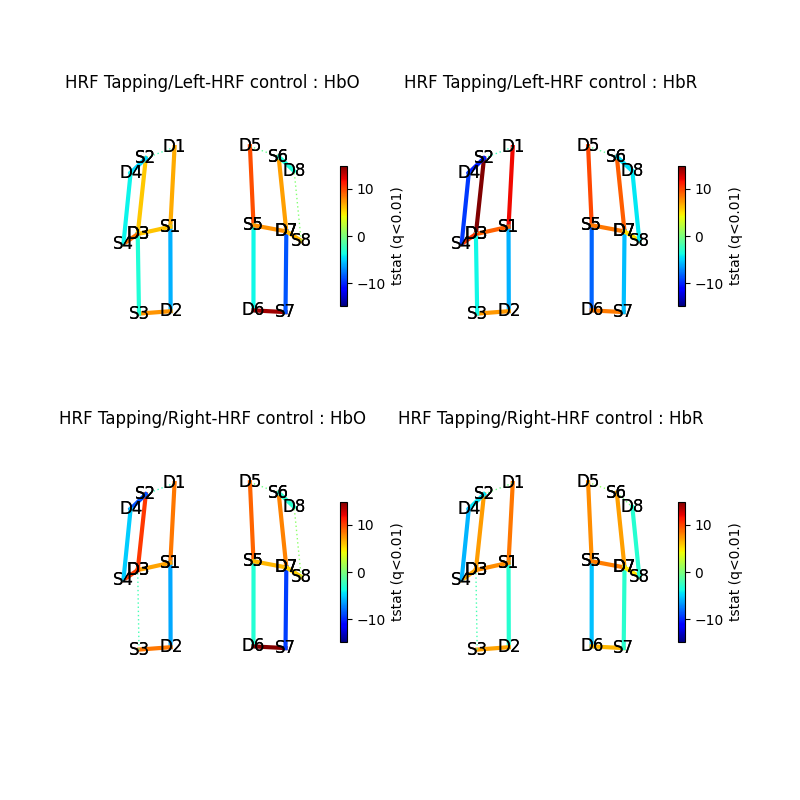

In [7]:
stats.draw(vartype='tstat',thresh='q<0.01')